In [1]:
#TODO rerun due to prepare change
#also adjsut shgo to use complex/2vec represnation

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.direct.logit_based import EnergyConfidence
from confidence.direct.refiner import GaussianSmoothingRefiner
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.prototype import ClassPrototypeConfidence
from confidence.utils import ModelInputOutputWrapper
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.sampling import BatchNegativeSampler
from utils.transformation_problem import TransformationProblem

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = 60

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [4]:
dataset_info

Box({'input_size': (1, 40, 40), 'num_classes': 10, 'transform_seq_name': 'biggermnist_default', 'datatype': 'image', 'name': 'bigger_mnist', 'resample_method': 'grid_resample', 'pad': 6, 'epochs': 100, 'batch_size': 128, 'batch_size_search': 1024})

In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

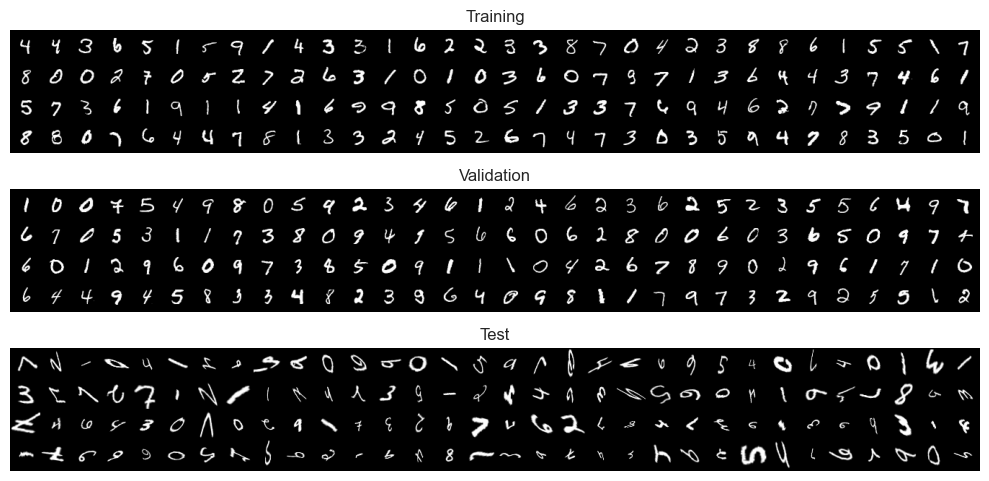

In [6]:
from utils.eval.vis import vis_dataset
batch_size = next(iter(train_loader))[0].shape[0]
vis_dataset(train_loader,val_loader,test_loader_transformed)

In [7]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")

transform_seq_name = dataset_info.transform_seq_name

# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,transform_seq_name, "uncertainty")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [8]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [9]:
model.eval().to(device)
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


{'accuracy': 0.9955999851226807, 'f2_macro': 0.9955340027809143, 'f2_micro': 0.9955999851226807, 'f2_weighted': 0.9955984354019165}


In [10]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]



In [11]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)
from utils.replacer import replace_rotation_transforms_2vec
if dataset =="modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)


In [12]:
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

from torch.utils.data import SequentialSampler
import embedding_cache
import importlib
importlib.reload(embedding_cache)
from embedding_cache import LayerEmbeddingCache
from confidence.input_transform import RandomProjectionModule


transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)

In [13]:
cache_config

Box({'cache_name_train': 'bigger_mnist_resnet_small__1024_embedding_cache_train', 'dim': 1024, 'reducer_name': ['image_transform', 'collapse_image', 'rp'], 'reducer_kwargs': [{'reduce_dims': (3, 3), 'rp_dim': 1024, 'average_pool': True}, {}, {'n_components': 1024, 'method': 'gaussian'}], 'reducer_dim_threshold': [(1025, None), (1025, None), (1025, 20000)], 'reducer_fit_batches': 0})

In [14]:
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [15]:
from search.shgo import SHGO
shgo  = SHGO(initial_samples=46,local_runs=2,local_max_steps=3)

In [16]:
model.cuda()
model.eval()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [17]:
import torch
import torch.nn.functional as F

model.cuda()


@torch.no_grad()
def check_softmax_confidence(model, dataloader, device=device):
    model.eval()
    mean_terms, trace_terms = [], []
    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        p = F.softmax(logits, dim=1)

        # Binary-like curvature term (true class only)
        # For binary: p(1-p)
        # For multi-class: p_y(1-p_y) where y is the true class
        true_p = p.gather(1, y.unsqueeze(1)).squeeze()
        p1mp = true_p * (1 - true_p)

        # Multi-class curvature trace term
        # Trace of softmax Hessian: tr(H) = sum_i p_i(1 - p_i) = 1 - sum_i p_i^2
        trace_term = 1 - (p ** 2).sum(dim=1)

        mean_terms.append(p1mp.cpu())
        trace_terms.append(trace_term.cpu())

    mean_terms = torch.cat(mean_terms)
    trace_terms = torch.cat(trace_terms)

    print(f"[DEBUG] mean p_y(1-p_y): {mean_terms.mean():.3e}")
    print(f"[DEBUG] mean trace(softmax hessian): {trace_terms.mean():.3e}")
    print(f"[DEBUG] fraction p_y(1-p_y) < 1e-3: {(mean_terms < 1e-3).float().mean():.2%}")
    print(f"[DEBUG] fraction trace < 1e-3: {(trace_terms < 1e-3).float().mean():.2%}")

    return mean_terms, trace_terms


@torch.no_grad()
def check_feature_scale(dual_model, dataloader, device=device):
    dual_model.eval()  # Fixed: was checking model.eval() instead of dual_model
    all_feats = []
    for x, _ in dataloader:
        x = x.to(device)
        feats, logits = dual_model(x)
        all_feats.append(feats.detach().cpu())
    all_feats = torch.cat(all_feats)
    print(f"[DEBUG] feature norm mean: {all_feats.norm(dim=1).mean():.3e}")
    print(f"[DEBUG] feature norm std: {all_feats.norm(dim=1).std():.3e}")
    return all_feats


check_softmax_confidence(model, train_loader_no_shuffle)
dual_model = train_cache.make_wrapper(target_layer_names="fc", capture_modes="input").to(device)
check_feature_scale(dual_model, train_loader_no_shuffle)

[DEBUG] mean p_y(1-p_y): 2.915e-08
[DEBUG] mean trace(softmax hessian): 5.831e-08
[DEBUG] fraction p_y(1-p_y) < 1e-3: 100.00%
[DEBUG] fraction trace < 1e-3: 100.00%
[DEBUG] feature norm mean: 1.730e+01
[DEBUG] feature norm std: 2.774e+00


tensor([[ 0.2860, -0.1334,  0.6520,  ...,  0.0042,  1.1632,  0.4307],
        [ 0.0942, -0.1063, -0.1343,  ..., -0.0791, -0.1617, -0.1347],
        [ 0.5510, -0.0699,  0.1542,  ...,  0.1872,  1.2036,  0.5368],
        ...,
        [ 0.6752, -0.0038,  0.2202,  ...,  0.1627,  1.3636,  0.5959],
        [ 0.5374, -0.1355, -0.1088,  ...,  0.0180, -0.1217, -0.1160],
        [-0.1311, -0.1080, -0.0497,  ..., -0.1217, -0.1364, -0.0439]])

In [18]:
import experiment_thesis.ood.base_prepare
experiment_thesis.ood.base_prepare.OOD_PARAM_SAMPLERS

{'energy': <function experiment_thesis.ood.direct.energy_prepare.sample_energy_params(trial: optuna.trial._trial.Trial, **kwargs) -> Dict[str, Any]>,
 'energy_ts': <function experiment_thesis.ood.direct.energy_prepare.sample_energy_ts_params(trial: optuna.trial._trial.Trial, **kwargs) -> Dict[str, Any]>,
 'max_logit': <function experiment_thesis.ood.direct.logit_based_prepare.sample_max_logit_params(trial: optuna.trial._trial.Trial) -> Dict[str, Any]>,
 'entropy': <function experiment_thesis.ood.direct.prob_prepare.sample_entropy_params(trial: optuna.trial._trial.Trial) -> Dict[str, Any]>,
 'max_softmax': <function experiment_thesis.ood.direct.prob_prepare.sample_max_softmax_params(trial: optuna.trial._trial.Trial) -> Dict[str, Any]>,
 'differentiable_max_softmax': <function experiment_thesis.ood.direct.prob_prepare.sample_diff_max_params(trial: optuna.trial._trial.Trial) -> Dict[str, Any]>,
 'adjusted_entropy': <function experiment_thesis.ood.direct.prob_prepare.sample_adjusted_entrop

In [19]:
from utils.affine_transforms import AffineTransformations3D,AffineTransformation2D
from utils.transform_sequence import TransformSequence
from utils.transformation_problem import TransformationProblem

def replace_rotation_transforms(problem):
    """
    Creates a copy of the problem with rotation transformations replaced.
    - 2D rotations are replaced by ROTATION_COMPLEX
    - 3D rotations are replaced by ROTATION_QUATERNION
    - Domains for rotation transforms are set to None

    Args:
        problem: TransformationProblem to modify

    Returns:
        New TransformationProblem with rotations replaced
    """
    original_sequence = problem.transform_sequence
    transformations = original_sequence.transformations
    domains = original_sequence.domains

    # Check if modification is needed
    needs_update = False
    for t in transformations:
        # Check for 2D rotation (enum value or class)
        if hasattr(AffineTransformation2D, 'ROTATION') and t == AffineTransformation2D.ROTATION.value:
            needs_update = True
            break
        # Check for 3D rotation (enum value or class)
        if hasattr(AffineTransformations3D, 'ROTATION') and t == AffineTransformations3D.ROTATION.value:
            needs_update = True
            break
        if hasattr(AffineTransformations3D, 'ROTATION_EULER') and t == AffineTransformations3D.ROTATION_EULER.value:
            needs_update = True
            break

    if not needs_update:
        return problem

    # Build new transformations and domains
    new_transformations = []
    new_domains = []

    for i, t in enumerate(transformations):
        replaced = False

        # Check for 2D rotation
        if hasattr(AffineTransformation2D, 'ROTATION') and t == AffineTransformation2D.ROTATION.value:
            new_transformations.append(AffineTransformation2D.ROTATION_COMPLEX.value)
            new_domains.append(None)
            replaced = True

        # Check for 3D rotation (standard)
        if not replaced and hasattr(AffineTransformations3D, 'ROTATION') and t == AffineTransformations3D.ROTATION.value:
            new_transformations.append(AffineTransformations3D.ROTATION_QUATERNION.value)
            new_domains.append(None)
            replaced = True

        # Check for 3D Euler rotation
        if not replaced and hasattr(AffineTransformations3D, 'ROTATION_EULER') and t == AffineTransformations3D.ROTATION_EULER.value:
            new_transformations.append(AffineTransformations3D.ROTATION_QUATERNION.value)
            new_domains.append(None)
            replaced = True

        # Keep original if not replaced
        if not replaced:
            new_transformations.append(t)
            new_domains.append(domains[i])

    # Create new TransformSequence
    new_sequence = TransformSequence(
        transformations=new_transformations,
        domains=new_domains,
        neighbour_hood_size=original_sequence.neighbour_hood_size,
        application_method=original_sequence.application_method,
        device=original_sequence.dummy_param.device,
        dtype=original_sequence.dummy_param.dtype,
        init_method=original_sequence.init_method,
        reflect=original_sequence.reflect,
        invert=original_sequence.invert
    )

    # Create new TransformationProblem
    from utils.transformation_problem import TransformationProblem
    new_problem = TransformationProblem(
        confidence_module=problem.confidence_module,
        transform_sequence=new_sequence,
        consolidate_method=problem.consolidate_method,
        max_batch_size=problem.max_batch_size
    )

    return new_problem

In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [21]:
import os
import json
from datetime import datetime
import optuna

from experiment_thesis.ood.base_prepare import (
    run_ood_study,
    get_default_ood_params,
    get_best_ood_params_from_study,
    create_ood_problem,
)
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

# configure
detectors = ["laplace_entropy_plus_mi","energy","max_logit","entropy","max_softmax","kl_matching","mc_batchnorm_energy","mc_batchnorm_prob","mc_batchnorm_variance","mc_batchnorm_mi","laplace_prob","laplace_energy","laplace_mi","laplace_variance",]#"gradnorm"] gradnorm is to bad and ruins plot. Not sure why.
objectives_to_run = ["search"]  # adapt as needed
n_trials = 0
optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0)   # only needed if using "search" objective

skip = False #skips construction of problems.
if not skip:
    for detector in detectors:
        best_params = get_default_ood_params(detector)

        #Recreate problem with best params
        problem = create_ood_problem(
                detector_name=detector,
                params=best_params,
                model=model,
                train_cache=train_cache,
                transform_seq=transform_seq,
                dataset_info=dataset_info,
                architecture=architecture,
                device=str(device),
        )
        problem = replace_rotation_transforms(problem)


        #
        eval_path = os.path.join(results_dir_path, f"eval_{detector}_default.json")
        print(f"  Evaluating final {detector} with best params (cache: {eval_path})")

        metrics = load_or_run_evaluate_confidence_and_search(
                model=model,
                optimizer=optimizer,
                problem=problem,
                test_loader=test_loader_transformed,
                save_path=eval_path,
                max_batch_override=dataset_info.batch_size_search if detector != "gradnorm" else 128,
                show_progress=True,
                repeats=8,
                return_per_run=True,
                overwrite=False,
                store_val=False,
        )
        print(f"  Evaluation metrics saved -> {eval_path}")



prior precision at init: 1.0
prior precision after init: 1.0


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\laplace\baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(


[DEBUG] Block 0: weights (A⊗B), shapes torch.Size([10]) × torch.Size([512])
[DEBUG] Block 1: single (bias), shape torch.Size([10])

=== Hessian Eigenvalue Diagnostics ===
Hessian type: KronDecomposed
Total eigenvalues: 5,130
Range: [0.000e+00, 4.989e-02]
Mean: 1.977e-04
Negatives: 0

Stored fitted Laplace into in-memory cache (key=28476379d2e50b03d546c5b924208131c8543a8a115d52de3bad3c7ede82f4b4|||marglik|()|nn|mc)
  Evaluating final laplace_entropy_plus_mi with best params (cache: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\eval_laplace_entropy_plus_mi_default.json)

  Evaluation metrics saved -> C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\eval_laplace_entropy_plus_mi_default.json
  Evaluating final energy with best params (cache: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\re

In [22]:
import pandas as pd

results = []
for detector in detectors:
    eval_path = os.path.join(results_dir_path, f"eval_{detector}_default.json")
    if os.path.exists(eval_path):
        with open(eval_path, "r") as f:
            metrics = json.load(f)
        accuracy = metrics.get("accuracy_mean", None)
        accuracy_se = metrics.get("accuracy_se", None)
        results.append({
            "Algorithm": detector,
            "Accuracy": accuracy,
            "Accuracy_SE": accuracy_se
        })
    else:
        print(f"Warning: {eval_path} not found.")

# Convert to DataFrame
df = pd.DataFrame(results)
print(df.head())


                 Algorithm  Accuracy  Accuracy_SE
0  laplace_entropy_plus_mi  0.316988     0.001454
1                   energy  0.790500     0.001082
2                max_logit  0.789750     0.001235
3                  entropy  0.803687     0.000969
4              max_softmax  0.726575     0.000936


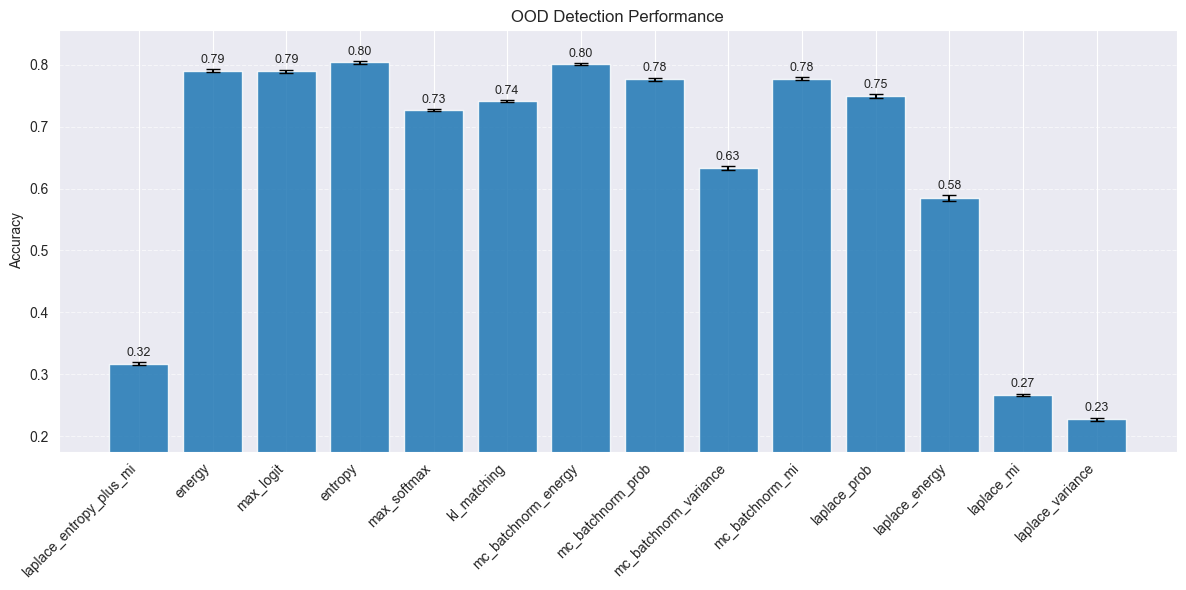

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Single problem, multiple algorithms
algorithms = df["Algorithm"].tolist()
accuracies = df["Accuracy"].values
errors = df["Accuracy_SE"].values *1.96

fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df))
bars = ax.bar(
    x_pos,
    accuracies,
    yerr=errors,
    capsize=5,
    alpha=0.85
)

# Add data labels on top of bars
for i, (acc, err) in enumerate(zip(accuracies, errors)):
    ax.text(i, acc + err + 0.01, f"{acc:.2f}", ha='center', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(algorithms, rotation=45, ha="right")

# Dynamically calculate y-limits
ymin = max(0, (accuracies - errors).min() - 0.05)
ymax = min(1, (accuracies + errors).max() + 0.05)
ax.set_ylim(ymin, ymax)

ax.set_ylabel("Accuracy")
ax.set_title("OOD Detection Performance")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [24]:
#for testing mc dropout we need a new model with dropout layers
model_mc = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname_mc = f"{dataset}_{architecture}_mc"
#now we need to modilfy it
from experiment_thesis.dataset_preperation.basic_networks import convert_flexible_resnet_to_dropout_sequential
model_mc = convert_flexible_resnet_to_dropout_sequential(model_mc, dropout_p=0.5)
#now we need to train it
train_and_get_model(model_mc,model_dir_path,modelname_mc, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_mc.safetensors


(Sequential(
   (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (2): GELU(approximate='none')
   (3): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (act): GELU(approximate='none')
     )
   )
   (4): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [25]:
model_mc.eval().to(device)

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    )
  )
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  

In [26]:
#call model twice with sample input and test determinism
sample_input = torch.randn(1, *dataset_info.input_size).to(device)
out1 = model_mc(sample_input)
out2 = model_mc(sample_input)
print("Outputs are identical:", torch.allclose(out1, out2))

Outputs are identical: True


In [27]:
#test model on test set
res = evaluate_base_model(model_mc, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model_mc, test_loader, device)
print(res)

{'accuracy': 0.374099999666214, 'f2_macro': 0.3661237955093384, 'f2_micro': 0.374099999666214, 'f2_weighted': 0.3681815564632416}


{'accuracy': 0.994700014591217, 'f2_macro': 0.9946026802062988, 'f2_micro': 0.994700014591217, 'f2_weighted': 0.9946975708007812}


In [28]:
dual_model = ModelInputOutputWrapper(model_mc, target_layer_names="10", capture_modes="input",return_y=False).to(device)

In [29]:
embeddings_t = []
logits_t = []
classes_t = []
model_mc.eval()
with torch.no_grad():
    for x, y in train_loader_no_shuffle:
        x = x.to(device)
        y = y.to(device)
        feats, logits = dual_model(x)
        classes_t.append(y.detach().cpu())
        embeddings_t.append(feats.detach().cpu())
        logits_t.append(logits.detach().cpu())
embeddings_t = torch.cat(embeddings_t)
logits_t = torch.cat(logits_t)
classes_t = torch.cat(classes_t)

In [30]:
from confidence.unsupervised.classic.prototype import ClassPrototypeConfidence
from confidence.control.split import PredictedSplitConfidence

nn_pytorch_pretrained = ClassPrototypeConfidence(metric="cosine", input_transform=None)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model_mc.eval().to(device)

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    )
  )
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  

In [31]:
metrics_nn = load_or_run_evaluate_confidence_and_search(
            model=model_mc,
            optimizer=optimizer,
            problem=problem_nn_pytorch_pretrained,
            test_loader=test_loader_transformed,
            save_path=os.path.join(results_dir_path, f"mc_eval_nn_pytorch_pretrained.json"),
            max_batch_override=dataset_info.batch_size_search,
            show_progress=True,
            repeats=8,
            return_per_run=True,
            overwrite=False,
            store_val=False,
    )
print(f"  Evaluation metrics saved -> {os.path.join(results_dir_path, f'mc_eval_nn_pytorch_pretrained.json')}")


  Evaluation metrics saved -> C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\mc_eval_nn_pytorch_pretrained.json


In [32]:
detectors_mc = ["energy","entropy","mc_dropout_last_layer_energy","mc_dropout_last_layer_mi","mc_dropout_last_layer_entropy"]
objectives_to_run = ["search"]  # adapt as needed
n_trials = 0
optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0)   # only needed if using "search" objective
for detector in detectors_mc:
    print(detector)
    best_params = get_default_ood_params(detector)

    #Recreate problem with best params
    problem = create_ood_problem(
            detector_name=detector,
            params=best_params,
            model=model_mc,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )
    problem = replace_rotation_transforms(problem)
    #
    eval_path = os.path.join(results_dir_path, f"mc_eval_{detector}_default.json")
    print(f"  Evaluating final {detector} with best params (cache: {eval_path})")
    metrics = load_or_run_evaluate_confidence_and_search(
                model=model_mc,
                optimizer=optimizer,
                problem=problem,
                test_loader=test_loader_transformed,
                save_path=eval_path,
                max_batch_override=dataset_info.batch_size_search if detector != "gradnorm" else 128,
                show_progress=True,
                repeats=8,
                return_per_run=True,
                overwrite=False,
                store_val=False,
    )
    print(f"  Evaluation metrics saved -> {eval_path}")



energy
  Evaluating final energy with best params (cache: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\mc_eval_energy_default.json)

  Evaluation metrics saved -> C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\mc_eval_energy_default.json
entropy
  Evaluating final entropy with best params (cache: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\mc_eval_entropy_default.json)

  Evaluation metrics saved -> C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\resnet_small\biggermnist_default\uncertainty\mc_eval_entropy_default.json
mc_dropout_last_layer_energy
  Evaluating final mc_dropout_last_layer_energy with best params (cache: C:\Users\Lindner\PycharmProjects\experiments_rotation\

In [33]:
results_mc = []
for detector in detectors_mc:
    eval_path = os.path.join(results_dir_path, f"mc_eval_{detector}_default.json")
    if os.path.exists(eval_path):
        with open(eval_path, "r") as f:
            metrics = json.load(f)
        accuracy = metrics.get("accuracy_mean", None)
        accuracy_se = metrics.get("accuracy_se", None)
        results_mc.append({
            "Algorithm": detector,
            "Accuracy": accuracy,
            "Accuracy_SE": accuracy_se
        })
    else:
        print(f"Warning: {eval_path} not found.")

#also add prototype method
results_mc.append({
            "Algorithm": "mc_dropout_nn_pytorch_pretrained",
            "Accuracy": metrics_nn.get("accuracy_mean", None),
            "Accuracy_SE": metrics_nn.get("accuracy_se", None)
        })

# Convert to DataFrame
df_mc = pd.DataFrame(results_mc)
print(df_mc.head())

                       Algorithm  Accuracy  Accuracy_SE
0                         energy  0.727338     0.000969
1                        entropy  0.755588     0.000931
2   mc_dropout_last_layer_energy  0.728138     0.001353
3       mc_dropout_last_layer_mi  0.758525     0.000844
4  mc_dropout_last_layer_entropy  0.767575     0.000744


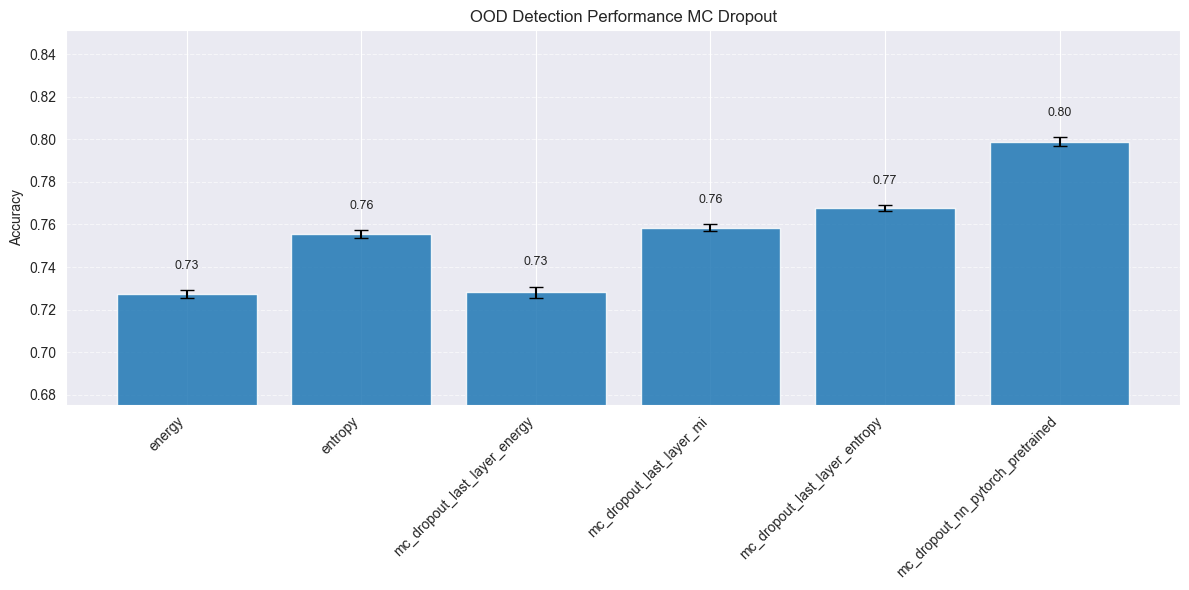

In [34]:
import matplotlib.pyplot as plt
import numpy as np
# Single problem, multiple algorithms
algorithms = df_mc["Algorithm"].tolist()
accuracies = df_mc["Accuracy"].values
errors = df_mc["Accuracy_SE"].values *1.96
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(df_mc))
bars = ax.bar(
    x_pos,
    accuracies,
    yerr=errors,
    capsize=5,
    alpha=0.85
)
# Add data labels on top of bars
for i, (acc, err) in enumerate(zip(accuracies, errors)):
    ax.text(i, acc + err + 0.01, f"{acc:.2f}", ha='center', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(algorithms, rotation=45, ha="right")
# Dynamically calculate y-limits
ymin = max(0, (accuracies - errors).min() - 0.05)
ymax = min(1, (accuracies + errors).max() + 0.05)
ax.set_ylim(ymin, ymax)
ax.set_ylabel("Accuracy")
ax.set_title("OOD Detection Performance MC Dropout")
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [35]:
from utils.eval.ood_performance import ITSWRAPPER
import importlib
import its.search
importlib.reload(its.search)

its2 = ITSWRAPPER(its.search.InverseTransformationSearch(model,None,None,n_hypotheses=1,n_samples=11,extend=0,gaussian_filter_channel_wise=True))


In [36]:
energy_problem = create_ood_problem(
            detector_name="energy",
            params=get_default_ood_params("energy"),
            model=model,
            train_cache=train_cache,
            transform_seq=transform_seq,
            dataset_info=dataset_info,
            architecture=architecture,
            device=str(device),
    )

In [37]:
class TwoInputSequential(nn.Module):
    def __init__(self, *args):
        super(TwoInputSequential, self).__init__()
        self.modules_list = nn.ModuleList(args)

    def forward(self, x, y):
        for module in self.modules_list:
            x = module(x, y)
        return x

In [38]:
from confidence.direct.refiner import CurvatureRefiner,GaussianSmoothingRefiner
from confidence.direct.logit_based import EnergyConfidence
from confidence.model.single_pass import SinglePassConfidence
from utils.transformation_problem import TransformationProblem
energy = EnergyConfidence()




its_energy_group_conf = SinglePassConfidence(model,refined)
problem_its_energy = TransformationProblem(
    confidence_module=None,
    transform_sequence=transform_seq,)

NameError: name 'refined' is not defined

In [ ]:
load_or_run_evaluate_confidence_and_search(model=model,
            optimizer=its2,
            problem=problem_its_energy,
            test_loader=test_loader_transformed,
            save_path=os.path.join(results_dir_path, f"its_eval_its_metric.json"),
            max_batch_override=dataset_info.batch_size_search if detector != "gradnorm" else 128,
            show_progress=True,
            repeats=2,
            return_per_run=True,
            overwrite=True,
            store_val=False,)

In [ ]:
load_or_run_evaluate_confidence_and_search(model=model,
            optimizer=its2,
            problem=energy_problem,
            test_loader=test_loader_transformed,
            save_path=os.path.join(results_dir_path, f"its_eval_default.json"),
            max_batch_override=dataset_info.batch_size_search if detector != "gradnorm" else 128,
            show_progress=True,
            repeats=2,
            return_per_run=True,
            overwrite=False,
            store_val=False,)

In [ ]:
#load as df
df_its = pd.read_json(os.path.join(results_dir_path, f"its_eval_its_metric.json"))
df_energy = pd.read_json(os.path.join(results_dir_path, f"its_eval_default.json"))

#plot them against each other
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
#df only contains accuracy_mean and accuracy_se
#plot barchart with two bars per group and error bars
labels = ['ITS Metric','Energy']
accuracy_means = [df_its['accuracy_mean'].values[0], df_energy['accuracy_mean'].values[0]]
accuracy_ses = [df_its['accuracy_se'].values[0], df_energy['accuracy_se'].values[0]]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
bars = ax.bar(x, accuracy_means, width, yerr=accuracy_ses, capsize=5, label='Accuracy', alpha=0.85)
# Add data labels on top of bars
for i, (acc, err) in enumerate(zip(accuracy_means, accuracy_ses)):
    ax.text(i, acc + err + 0.01, f"{acc:.2f}", ha='center', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('ITS vs Energy OOD Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)